In [ ]:
import numpy as np
from matplotlib import pyplot as plt

def FTCS(Qnj, Qnjforward, Qnjbackward, dt, dx, u, a):
    Qnforwardj = Qnj - (dt / dx) * u * (Qnj - Qnjbackward) + (dt / dx**2) * a * (Qnjforward - 2 * Qnj + Qnjbackward)
    return Qnforwardj

def plot(Q, T, numTs, Lx, numXs):
    fig = plt.figure(figsize = (10, 5))
    fig.suptitle('Solução da equação de advecção-difusão', fontsize = 16)

    # Plot 3D
    ax = fig.add_subplot(1, 1, 1, projection = '3d')
    x = np.linspace(0, Lx, numXs)
    t = np.linspace(0, T, numTs)
    X, T = np.meshgrid(x, t)
    
    surf = ax.plot_surface(X, T, Q, cmap = 'viridis')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_zlabel('c(x,t)')

    plt.show()
    
    

def apply(function, T, numTs, Lx, numXs, u, a, ca, cb):
    dt = T/numTs
    dx = Lx/numXs

    Q = np.zeros((numTs, numXs))

    # Condições iniciais
    Q[:, 0] = ca # c(x=0, t) = ca
    Q[0, :] = cb # c(x, t=0) = cb

    for n in range(0, numTs-1):
        for j in range(1, numXs-1):
            Q[n+1, j] = function(Q[n, j], Q[n, j+1], Q[n, j-1], dt, dx, u, a)

        # Condição de contorno com aproximação recuada de 1ª ordem
        Q[n+1, -1] = Q[n+1, -2]

    plot(Q, T, numTs, Lx, numXs)

    return Q


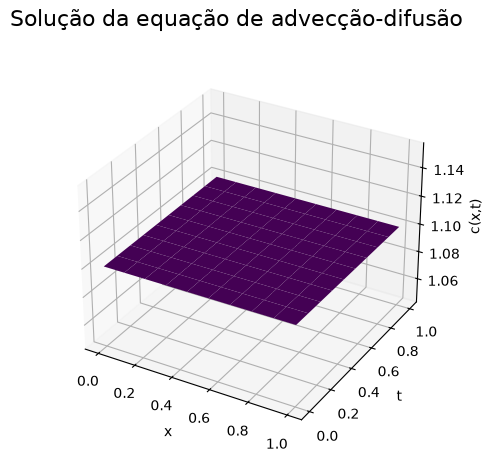

In [ ]:
def main():
    # Malha
    Lx = 1.0
    numXs = 10
    T = 1.0
    numTs = 10

    # Constantes
    u = 2.0
    a = 2.0

    # Condições iniciais
    ca = 1.1
    cb = 1.1

    apply(FTCS, T, numTs, Lx, numXs, u, a, ca, cb)

main()
